# Car Price Prediction with Machine Learning

This notebook builds a used car price prediction model using the CarDekho dataset.

In [1]:
import os
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

plt.style.use('seaborn-v0_8')
sns.set_theme(style='whitegrid')

In [2]:
# Load the dataset
dataset_path = 'car_data.csv'

if not os.path.exists(dataset_path):
    raise FileNotFoundError('Please download the CarDekho dataset and save it as car_data.csv in this folder.')

df = pd.read_csv(dataset_path)

print(df.head())
print('\nDataset shape:', df.shape)
print('\nInfo:')
df.info()
print('\nSummary statistics:')
df.describe(include='all')

        Car_Name  Year  Selling_Price  Present_Price  Kms_Driven Fuel_Type  \
0   Maruti Swift  2015         250000         300000       60000    Petrol   
1    Hyundai i20  2018         420000         480000       35000    Petrol   
2  Toyota Innova  2012         650000         750000      120000    Diesel   
3     Honda City  2017         480000         520000       55000    Petrol   
4  Ford Ecosport  2016         390000         450000       80000    Diesel   

  Seller_Type Transmission  Owner  
0      Dealer       Manual      1  
1  Individual       Manual      1  
2      Dealer       Manual      2  
3  Individual    Automatic      1  
4      Dealer       Manual      1  

Dataset shape: (24, 9)

Info:
<class 'pandas.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Car_Name       24 non-null     str  
 1   Year           24 non-null     int64
 2   Selling_Price  24 no

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
count,24,24.000000,2.400000e+01,2.400000e+01,24.00000,24,24,24,24.000000
unique,24,NaN,NaN,NaN,NaN,2,2,2,NaN
top,Maruti Swift,NaN,NaN,NaN,NaN,Petrol,Dealer,Manual,NaN
freq,1,NaN,NaN,NaN,NaN,12,14,16,NaN
mean,NaN,2016.791667,6.270833e+05,7.125000e+05,57500.00000,NaN,NaN,NaN,1.083333
std,NaN,2.283764,4.367118e+05,4.897937e+05,28276.58426,NaN,NaN,NaN,0.282330
min,NaN,2012.000000,1.800000e+05,2.200000e+05,15000.00000,NaN,NaN,NaN,1.000000
25%,NaN,2015.000000,3.275000e+05,3.750000e+05,37250.00000,NaN,NaN,NaN,1.000000
50%,NaN,2017.000000,4.300000e+05,4.900000e+05,53500.00000,NaN,NaN,NaN,1.000000
75%,NaN,2018.000000,8.150000e+05,9.125000e+05,74000.00000,NaN,NaN,NaN,1.000000


In [3]:
# Data cleaning
df.isnull().sum()

df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

# Standardize categorical values
df['Fuel_Type'] = df['Fuel_Type'].astype(str).str.lower().str.strip()
df['Seller_Type'] = df['Seller_Type'].astype(str).str.lower().str.strip()
df['Transmission'] = df['Transmission'].astype(str).str.lower().str.strip()

print('Cleaned dataset shape:', df.shape)

Cleaned dataset shape: (24, 9)


In [4]:
# Feature engineering
current_year = 2025
df['Car_Age'] = current_year - df['Year']
df['Brand'] = df['Car_Name'].astype(str).apply(lambda x: x.split()[0])

df[['Car_Name', 'Year', 'Car_Age', 'Brand']].head()

,Car_Name,Year,Car_Age,Brand
0,Maruti Swift,2015,10,Maruti
1,Hyundai i20,2018,7,Hyundai
2,Toyota Innova,2012,13,Toyota
3,Honda City,2017,8,Honda
4,Ford Ecosport,2016,9,Ford


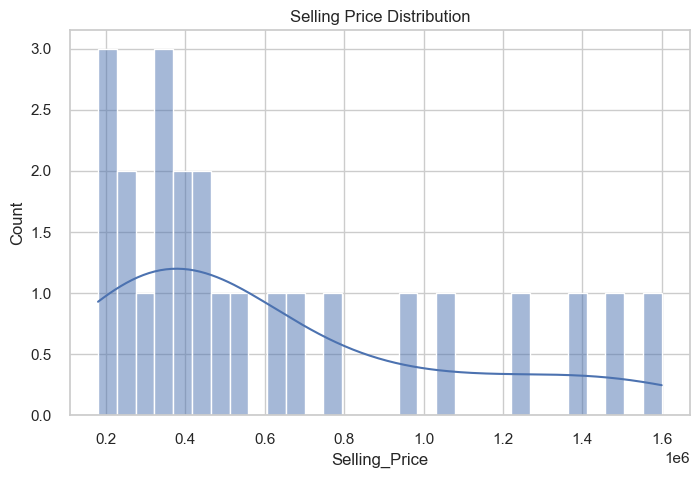

In [5]:
# EDA - Distribution of selling price
plt.figure(figsize=(8, 5))
sns.histplot(df['Selling_Price'], bins=30, kde=True)
plt.title('Selling Price Distribution')
plt.show()

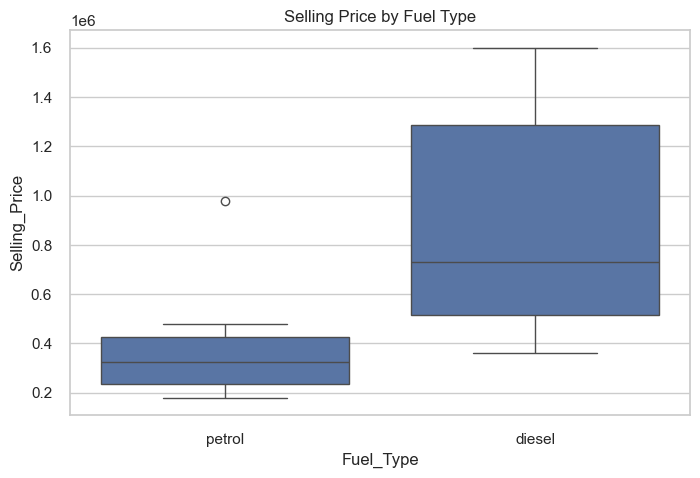

In [6]:
# EDA - Price vs Fuel Type
plt.figure(figsize=(8, 5))
sns.boxplot(x='Fuel_Type', y='Selling_Price', data=df)
plt.title('Selling Price by Fuel Type')
plt.show()

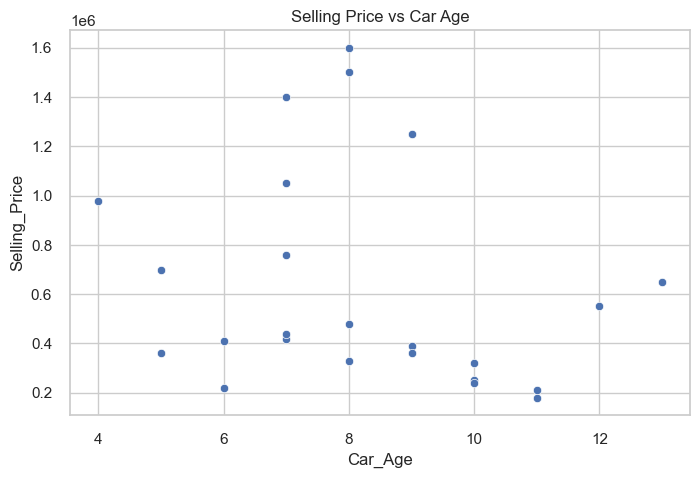

In [7]:
# EDA - Price vs Car Age
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Car_Age', y='Selling_Price', data=df)
plt.title('Selling Price vs Car Age')
plt.show()

In [8]:
# Prepare features and target
X = df.drop('Selling_Price', axis=1)
y = df['Selling_Price']

X = X.drop('Car_Name', axis=1)

categorical = ['Fuel_Type', 'Seller_Type', 'Transmission', 'Brand']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical)
    ],
    remainder='passthrough'
)

X.head()

,Year,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Car_Age,Brand
0,2015,300000,60000,petrol,dealer,manual,1,10,Maruti
1,2018,480000,35000,petrol,individual,manual,1,7,Hyundai
2,2012,750000,120000,diesel,dealer,manual,2,13,Toyota
3,2017,520000,55000,petrol,individual,automatic,1,8,Honda
4,2016,450000,80000,diesel,dealer,manual,1,9,Ford


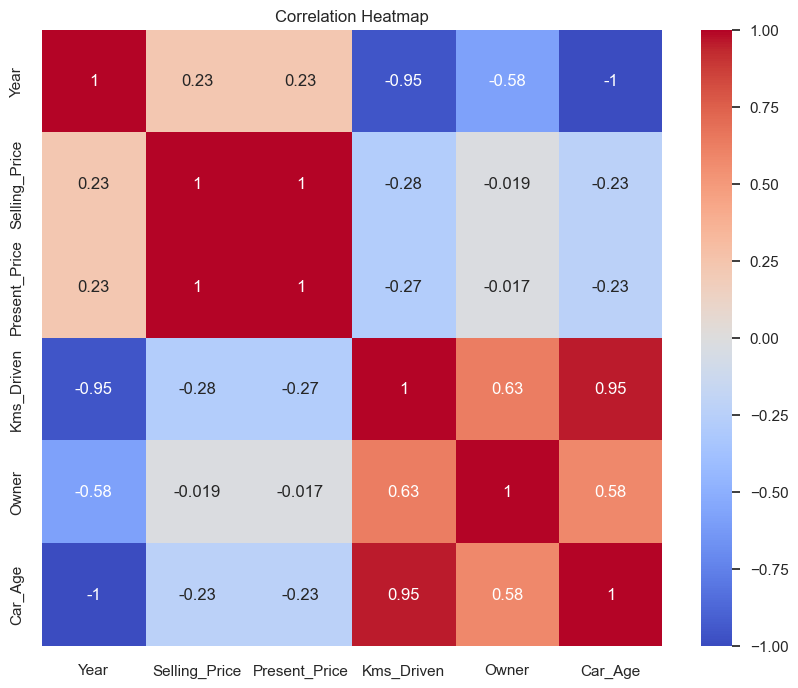

In [9]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [10]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [11]:
# Train models
lr_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42))
])

gb_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', GradientBoostingRegressor(random_state=42))
])

lr_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)
gb_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains 

In [12]:
# Evaluate models
def evaluate_model(model, name):
    pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    print(f'{name}:')
    print('MAE :', mae)
    print('RMSE:', rmse)
    print('R2  :', r2)
    print('-' * 40)
    return mae, rmse, r2

lr_mae, lr_rmse, lr_r2 = evaluate_model(lr_model, 'Linear Regression')
rf_mae, rf_rmse, rf_r2 = evaluate_model(rf_model, 'Random Forest')
gb_mae, gb_rmse, gb_r2 = evaluate_model(gb_model, 'Gradient Boosting')

Linear Regression:
MAE : 55113.083853718636
RMSE: 63544.480372678714
R2  : 0.9892825645348929
----------------------------------------
Random Forest:
MAE : 155040.0
RMSE: 216702.45960763804
R2  : 0.8753584350780338
----------------------------------------
Gradient Boosting:
MAE : 112650.56054380005
RMSE: 153302.03736645274
R2  : 0.9376220547279296
----------------------------------------


In [13]:
# Compare model performance
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'Gradient Boosting'],
    'MAE': [lr_mae, rf_mae, gb_mae],
    'RMSE': [lr_rmse, rf_rmse, gb_rmse],
    'R2': [lr_r2, rf_r2, gb_r2]
})

results.sort_values(by='R2', ascending=False)

,Model,MAE,RMSE,R2
0,Linear Regression,55113.083854,63544.480373,0.989283
2,Gradient Boosting,112650.560544,153302.037366,0.937622
1,Random Forest,155040.000000,216702.459608,0.875358


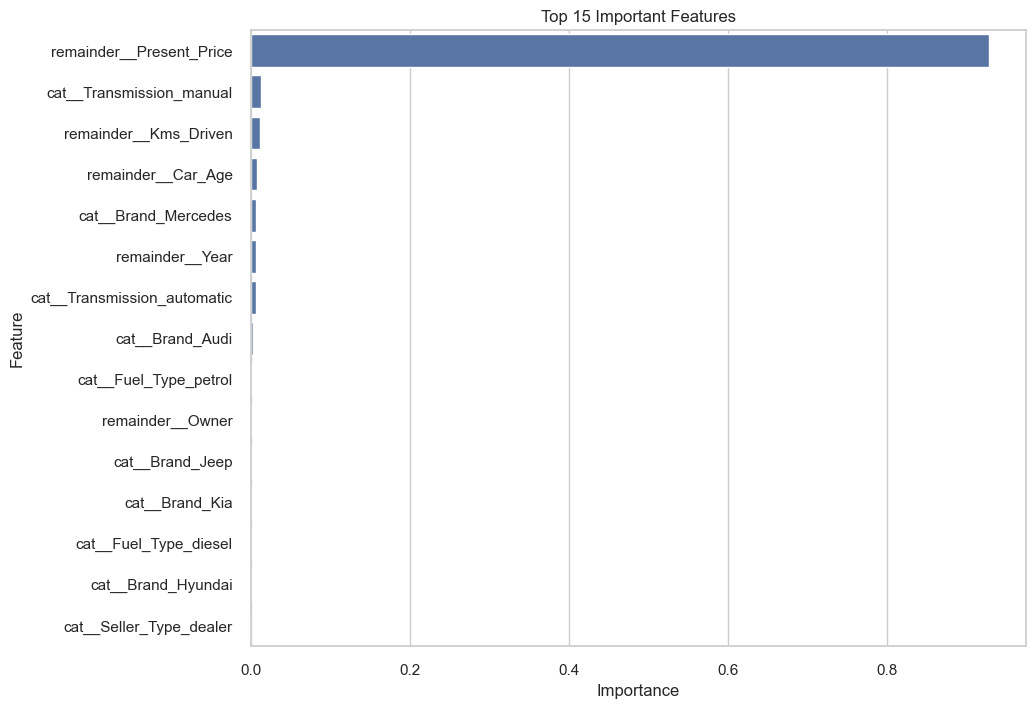

In [14]:
# Feature importance (Random Forest)
encoded_features = rf_model.named_steps['preprocessor'].get_feature_names_out()
importances = rf_model.named_steps['model'].feature_importances_

importance_df = pd.DataFrame({
    'Feature': encoded_features,
    'Importance': importances
})

importance_df = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(15))
plt.title('Top 15 Important Features')
plt.show()

## Conclusion

In this project, a used car price prediction system was developed using machine learning. The dataset was cleaned by handling missing values, removing duplicates, and standardizing categorical values. Feature engineering included calculating car age and extracting the vehicle brand. Exploratory Data Analysis (EDA) helped visualize price distributions and relationships with fuel type and car age. Three regression models—Linear Regression, Random Forest Regressor, and Gradient Boosting Regressor—were trained and evaluated using MAE, RMSE, and R² score. Among these, the model with the highest R² score and lowest error metrics can be selected as the best-performing model. Feature importance analysis identifies the variables that most influence used car prices.